# Predicción de Accidentes de Tráfico en Estados Unidos Utilizando un Enfoque de Voting Classifier con Machine Learning

## 📄 Resumen

Este proyecto busca desarrollar un modelo de predicción de accidentes de tráfico en Estados Unidos utilizando técnicas avanzadas de Machine Learning. A través de la integración de varios modelos predictivos mediante un Voting Classifier, se pretende mejorar la precisión y robustez del sistema predictivo en comparación con modelos individuales. La metodología empleada combina el preprocesamiento de datos, la selección de características, el equilibrio de clases, grid search, validación cruzada y validación del modelo resultante haciendo uso de pipelines.

---

## 🧪 Metodología

### 🎯 Población:
Accidentes vehiculares registrados en los Estados Unidos desde el año 2016.

### 🧾 Muestra:
Accidentes registrados en **California** durante el año **2022**, para reducir carga computacional y centrarse en el estado con más accidentes.

---

### 🔁 Flujo de trabajo:

1. **Recopilación de Datos**  
   Variables como clima, ubicación, hora del día, etc.

2. **Preprocesamiento**  
   Limpieza, codificación de variables, escalado con `StandardScaler`.

3. **Equilibrio de clases**  
   Se aplicaron técnicas como **SMOTE** y **ADASYN** debido al desbalance en la variable `severity`.

4. **Construcción de modelos individuales**  
   Cada modelo se entrenó con `GridSearchCV`, validación cruzada y sus respectivas optimizaciones.

5. **Voting Classifier final**  
   Se ensamblaron los mejores modelos usando votación **soft**.

6. **Evaluación del rendimiento**  
   Se usaron: Accuracy, Recall, F1-score, Matriz de Confusión, Curvas ROC.

---

## 🤖 Modelos de Machine Learning Implementados

### 🧠 1. Regresión Logística:
- Estimación de probabilidades para severidad del accidente.
- Se usó `solver='lbfgs'` por su eficiencia computacional.
- Regularización L2 (Ridge-like) para evitar sobreajuste.

### 🌳 2. Árbol de Decisión:
- Modelo interpretable que segmenta datos en reglas simples.
- Control de profundidad para evitar overfitting.

### 📏 3. SVM:
- Se implementó SVM con kernel RBF y también versión optimizada:
  - `RBFSampler` + `SGDClassifier` → reducción de tiempo del 88%.

### 📍 4. KNN:
- Clasificación basada en vecinos más cercanos.
- Se compararon `KD-Tree` vs `Ball-Tree`.
- **Ball-Tree** fue más rápido y se seleccionó como final.

### 📉 5. Ridge y Lasso:
- **RidgeClassifier** con regularización L2 (`solver='default'` más rápido que `saga`).
- **Lasso** implementado como regresión logística con penalización L1.

### 🚀 6. XGBoost:
- Algoritmo de boosting altamente eficiente.
- `tree_method='hist'` redujo tiempo de entrenamiento.
- Se aplicó `early_stopping_rounds` para prevenir sobreajuste.

### 🧪 7. Naive Bayes:
- Clasificador probabilístico simple y rápido.
- Entrenado con `partial_fit()` (batches).

### 💡 8. SGDClassifier:
- SVM lineal optimizado con descenso estocástico.
- Uso extendido junto a Fourier Features.

### 🧬 9. MLP (Perceptrón Multicapa):
- Red neuronal de tipo feedforward.
- Entrenada con función ReLU y una capa oculta.

### 🔄 10. RNN:
- Se aplicó para analizar secuencias temporales.
- Potencial para patrones dependientes del tiempo.

### 🧠 11. LSTM:
- Variante de RNN que maneja secuencias largas.
- Aplicada a series temporales como hora, duración, frecuencia de accidentes.

### 📊 12. CNN:
- Red neuronal convolucional 1D aplicada a vectores tabulares.
- Captura patrones espaciales internos en los datos.

### 🧭 13. Autoencoders:
- Usados para reducción de dimensionalidad y agrupación.
- Permitieron visualizar patrones no lineales en los datos de entrada.

---

### 🗳️ 14. Voting Classifier:
- Combina los modelos anteriores mediante votación **soft**.
- Obtuvo el **mejor desempeño global** en recall, F1-score y AUC.

---

## 📦 Diseño del Estudio

- Enfoque cuantitativo
- Validación mediante train-test split + cross validation
- Modelos ensamblados y comparados con métricas robustas

---

## 📚 Diccionario de Variables

## Diccionario de variables 

- ID: Identificador único de incidente
- Source: Fuente de la información
- Severity: Muestra la severidad del accidente, siendo 1 el menor impacto y 4 el  mayor.
- Start time y End Time: Tiempo de inicio y finalización del accidente.
- Start Lat, Start Lng, End Lat y End Lng: Latitudes y longitudes iniciales y finales.
- Distance: La longitud de la carretera recorrida en el incidente.
- Description: Descripción del accidente
- Street: Nombre de la calle del accidente.
- City, County, State, Country:  Ciudad, Condado, Estado y País.
- Zipcode: Código postal de la ubicación del accidente.
- Timezone: Zona de tiempo basado en la localización del accidente.
- Airport_Code: Código del aeropuerto.
- Weather_Timestamp:  Marca de tiempo del registro de observación meteorológica
- Wind_Chill (F),  Temperature (F), Humidity (%), Pressure (in), Wind direction (mph), Precipitation (in), Weather condition: Condiciones del ambiente de viento frío, humedad, presión, dirección del viento, precipitación.
- Visibility (mi): Visibilidad en millas.
- Amenity, Bump, Crossing, Give_way, Junction, No Exit, Roundabout, Station, Stop, Traffic Calming, Traffic_Signal, Turning_Loop:
Indica la presencia de una amenidad, baches, cruce, ceda el paso, unión, no salida, rotonda, estación, pare, pacificación del tráfico, señal de tr

---



## EDA

In [73]:
#from scikeras.wrappers import KerasClassifier

#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Conv1D, MaxPooling1D, Flatten
#from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import ADASYN
from lime.lime_tabular import LimeTabularExplainer
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import Lasso, LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.metrics import (accuracy_score, auc, classification_report, 
                             confusion_matrix, f1_score, precision_score, 
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import resample
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import calendar
import folium
import json
import klib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import warnings
from time import time

# Activar tema de seaborn
sns.set_theme()


In [74]:
warnings.filterwarnings("ignore")

In [75]:
df = pd.read_csv(r"C:\Users\jose_\OneDrive\Documentos guardados\Maestria analisis de datos\Machine Learning Likni\Machine learning Likir\Informe_Machine_Learning\US_Accidents_March23.csv")


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

Los datos iniciales constan de 7.728.394 de datos con 46 columnas, de las cuales 20 son categóricas, 13 booleanas y 13 númericas.

In [77]:
#Reducir el uso de la memoria
def reduce_mem_usage(df):

    start_mem = df.memory_usage(index=True, deep=True).sum() / 1024**2
    start_mem_GB = df.memory_usage(index=True, deep=True).sum() / 1024**3
    print(f'Initial memory usage of dataframe is {start_mem:.2f} MB/{start_mem_GB:.2f} GB')
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage(index=True, deep=True).sum() / 1024**2
    end_mem_GB = df.memory_usage(index=True, deep=True).sum() / 1024**3
    reduction = 100 * (start_mem - end_mem) / start_mem
    print(f'Memory usage after optimization is: {end_mem:.2f} MB/{end_mem_GB:.2f} GB')
    print(f'Decreased by {reduction:.1f}%')
    
    return df

In [78]:
df = reduce_mem_usage(df)

Initial memory usage of dataframe is 10870.28 MB/10.62 GB
Memory usage after optimization is: 3582.58 MB/3.50 GB
Decreased by 67.0%


In [79]:
Count= df["State"].value_counts()
df['Count'] = 1

df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['Month'] = df['Start_Time'].dt.month
df['Hour'] = df['Start_Time'].dt.hour
print(Count)

State
CA    1741433
FL     880192
TX     582837
SC     382557
NY     347960
NC     338199
VA     303301
PA     296620
MN     192084
OR     179660
AZ     170609
GA     169234
IL     168958
TN     167388
MI     162191
LA     149701
NJ     140719
MD     140417
OH     118115
WA     108221
AL     101044
UT      97079
CO      90885
OK      83647
MO      77323
CT      71005
IN      67224
MA      61996
WI      34688
KY      32254
NE      28870
MT      28496
IA      26307
AR      22780
NV      21665
KS      20992
DC      18630
RI      16971
MS      15181
DE      14097
WV      13793
ID      11376
NM      10325
NH      10213
WY       3757
ND       3487
ME       2698
VT        926
SD        289
Name: count, dtype: int64


Text(0.5, 1.0, 'Monthly Accident Count')

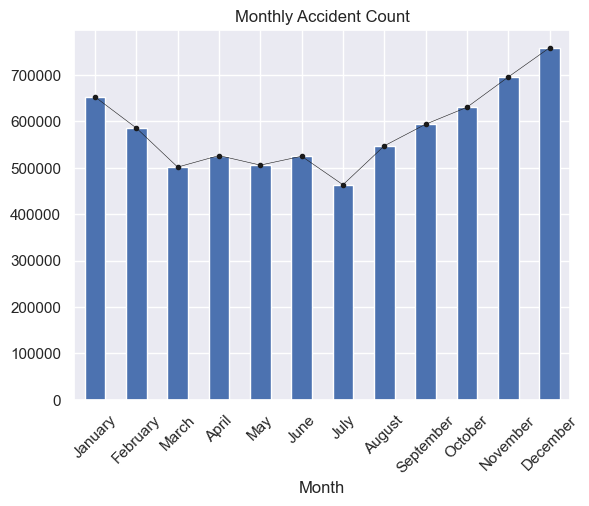

In [80]:

df.groupby('Month')['Count'].value_counts().plot(kind='bar')
df.groupby('Month')['Count'].value_counts().plot(color='k',linestyle='-',marker='.',linewidth=0.4)
plt.xticks(np.arange(12),calendar.month_name[1:13],rotation=45)
plt.xlabel('Month')
plt.title('Monthly Accident Count')

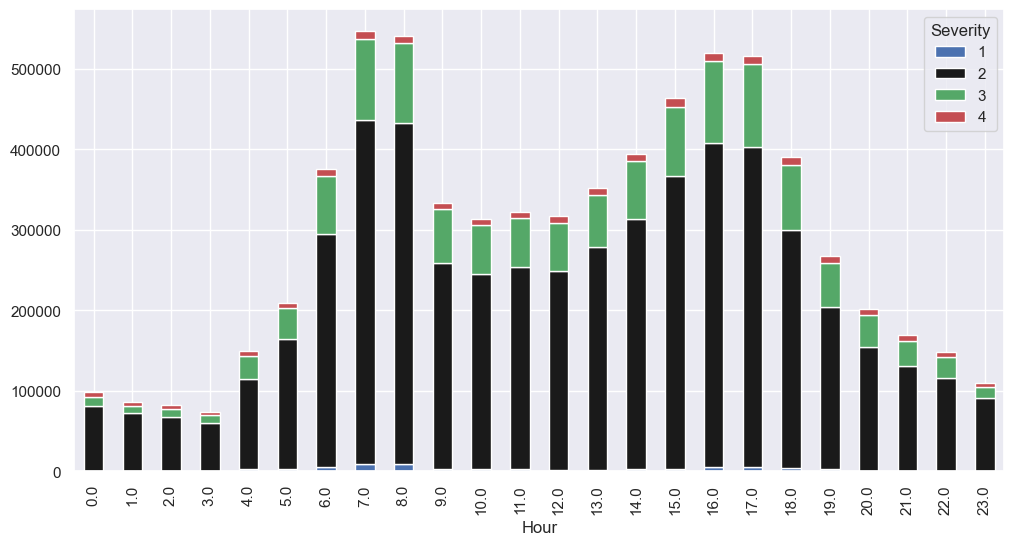

In [81]:
x = pd.crosstab(index=df['Hour'],columns=df['Severity'])
x.plot(kind='bar',stacked=True, color=['b','k','g','r','c'],figsize=(12,6))
plt.show()

In [82]:
w = df.groupby(['State'])['Count'].sum().reset_index()

In [83]:
state_geo = r'C:\Users\jose_\OneDrive\Documentos guardados\Maestria analisis de datos\Machine Learning Likni\Machine learning Likir\Informe_Machine_Learning\Json.json'

In [84]:
n = folium.Map(location=[39.381266, -97.922211],zoom_start=5)
folium.Choropleth(
 geo_data=state_geo,
 data=w,
 columns=['State', 'Count'],
 key_on='feature.id',
 fill_color='YlOrRd',
 fill_opacity=0.7,
 line_opacity=0.2,
 legend_name='Accidentes'
).add_to(n)
n

Se escoge el estado con mayor número de incidentes registrados, es decir, California.

In [85]:
state='CA'

df=df.loc[df.State==state].copy()
df.drop('State',axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1741433 entries, 728 to 7728393
Data columns (total 48 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   ID                     category      
 1   Source                 category      
 2   Severity               int8          
 3   Start_Time             datetime64[ns]
 4   End_Time               category      
 5   Start_Lat              float16       
 6   Start_Lng              float16       
 7   End_Lat                float16       
 8   End_Lng                float16       
 9   Distance(mi)           float16       
 10  Description            category      
 11  Street                 category      
 12  City                   category      
 13  County                 category      
 14  Zipcode                category      
 15  Country                category      
 16  Timezone               category      
 17  Airport_Code           category      
 18  Weather_Timestamp      ca

In [86]:
accidents_severity = df.groupby('Severity').count()['ID']
accidents_severity

Severity
1      10284
2    1445833
3     271814
4      13502
Name: ID, dtype: int64

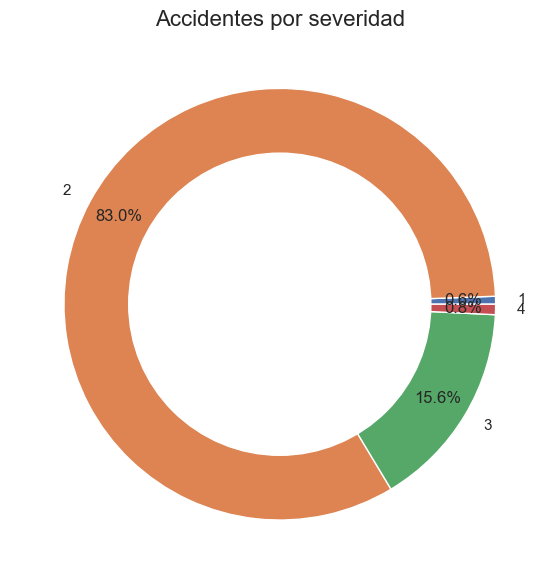

In [87]:
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(aspect="equal"))
label = [1,2,3,4]
plt.pie(accidents_severity, labels=label,
        autopct='%1.1f%%', pctdistance=0.85)
circle = plt.Circle( (0,0), 0.7, color='white')
p=plt.gcf()
p.gca().add_artist(circle)
ax.set_title("Accidentes por severidad",fontdict={'fontsize': 16})
plt.tight_layout()
plt.show()

Se utiliza la libreria Klib para realizar la limpieza de los datos, colocar en minúsculas las variables, cambiar los espacios por guión bajo, eliminar las características que toman un único valor (variables redundantes).

In [88]:
df = klib.data_cleaning(df)

Shape of cleaned data: (1741433, 45) - Remaining NAs: 3339084


Dropped rows: 0
     of which 0 duplicates. (Rows (first 150 shown): [])

Dropped columns: 3
     of which 3 single valued.     Columns: ['country', 'turning_loop', 'count']
Dropped missing values: 0
Reduced memory by at least: 109.35 MB (-9.47%)



A continuación se realiza la transformación de las columnas start_time y end_time en año, mes, día, hora y día de la semana. Esto debido a la posible influencia de estas variables en la frecuencia de los accidentes.

Adicionalmente, se calcula la duración de los accidentes y se eliminan datos incoherentes (tiempos < 0).

In [89]:
df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
df['end_time'] = pd.to_datetime(df['end_time'], errors='coerce')


df['Year'] = df['start_time'].dt.year
df['Month'] = df['start_time'].dt.month  # Changed to give numeric month
df['Day'] = df['start_time'].dt.day
df['Hour'] = df['start_time'].dt.hour
df['Weekday'] = df['start_time'].dt.weekday  # Changed to give numeric weekday (Monday=0, Sunday=6)


td = 'Duracion(min)'
df[td] = round((df['end_time'] - df['start_time']) / np.timedelta64(1, 'm'))


df.drop(["start_time", "end_time"], axis=1, inplace=True)


In [90]:
df[td][df[td]<=0]

Series([], Name: Duracion(min), dtype: float64)

Se realizará el análisis con los datos de incidentes a partir del año 2022, se tomó esta decisión por procesamiento y por evitar información atípica en el período de pandemia por el COVID-19.

In [91]:
df = df[df["Year"] >= 2022]

In [92]:
df.head()

,id,source,severity,start_lat,start_lng,end_lat,end_lng,distance_mi,description,street,...,nautical_twilight,astronomical_twilight,month,hour,Year,Month,Day,Hour,Weekday,Duracion(min)
175167,A-512231,Source2,1,34.53125,-117.9375,NaN,NaN,0.0,Crash on CA-138 Pearblossom Hwy at 96th St.,Pearblossom Hwy,...,Night,Night,9.0,2.0,2022.0,9.0,8.0,2.0,3.0,149.0
175168,A-512257,Source2,1,34.18750,-118.8750,NaN,NaN,0.0,Crash on US-101 Southbound before Exit 44 Moor...,US-101,...,Night,Night,9.0,2.0,2022.0,9.0,8.0,2.0,3.0,29.0
175169,A-512277,Source2,3,38.59375,-121.5000,NaN,NaN,0.0,#1 lane blocked due to crash on I-5 Northbound...,I-5,...,Night,Night,9.0,21.0,2022.0,9.0,7.0,21.0,2.0,44.0
175170,A-512340,Source2,2,33.84375,-117.8750,NaN,NaN,0.0,HOV lane blocked due to crash on CA-57 Southbo...,CA-57,...,Night,Night,9.0,2.0,2022.0,9.0,8.0,2.0,3.0,30.0
175171,A-512341,Source3,1,33.87500,-118.0000,NaN,NaN,0.0,Crash on Valley View Ave at I-5.,Firestone Blvd,...,Night,Night,9.0,2.0,2022.0,9.0,8.0,2.0,3.0,29.0


#### Selección de variables númericas y categóricas

Se revisarán las columnas númericas, para hacer la selección e imputación correspondiente.

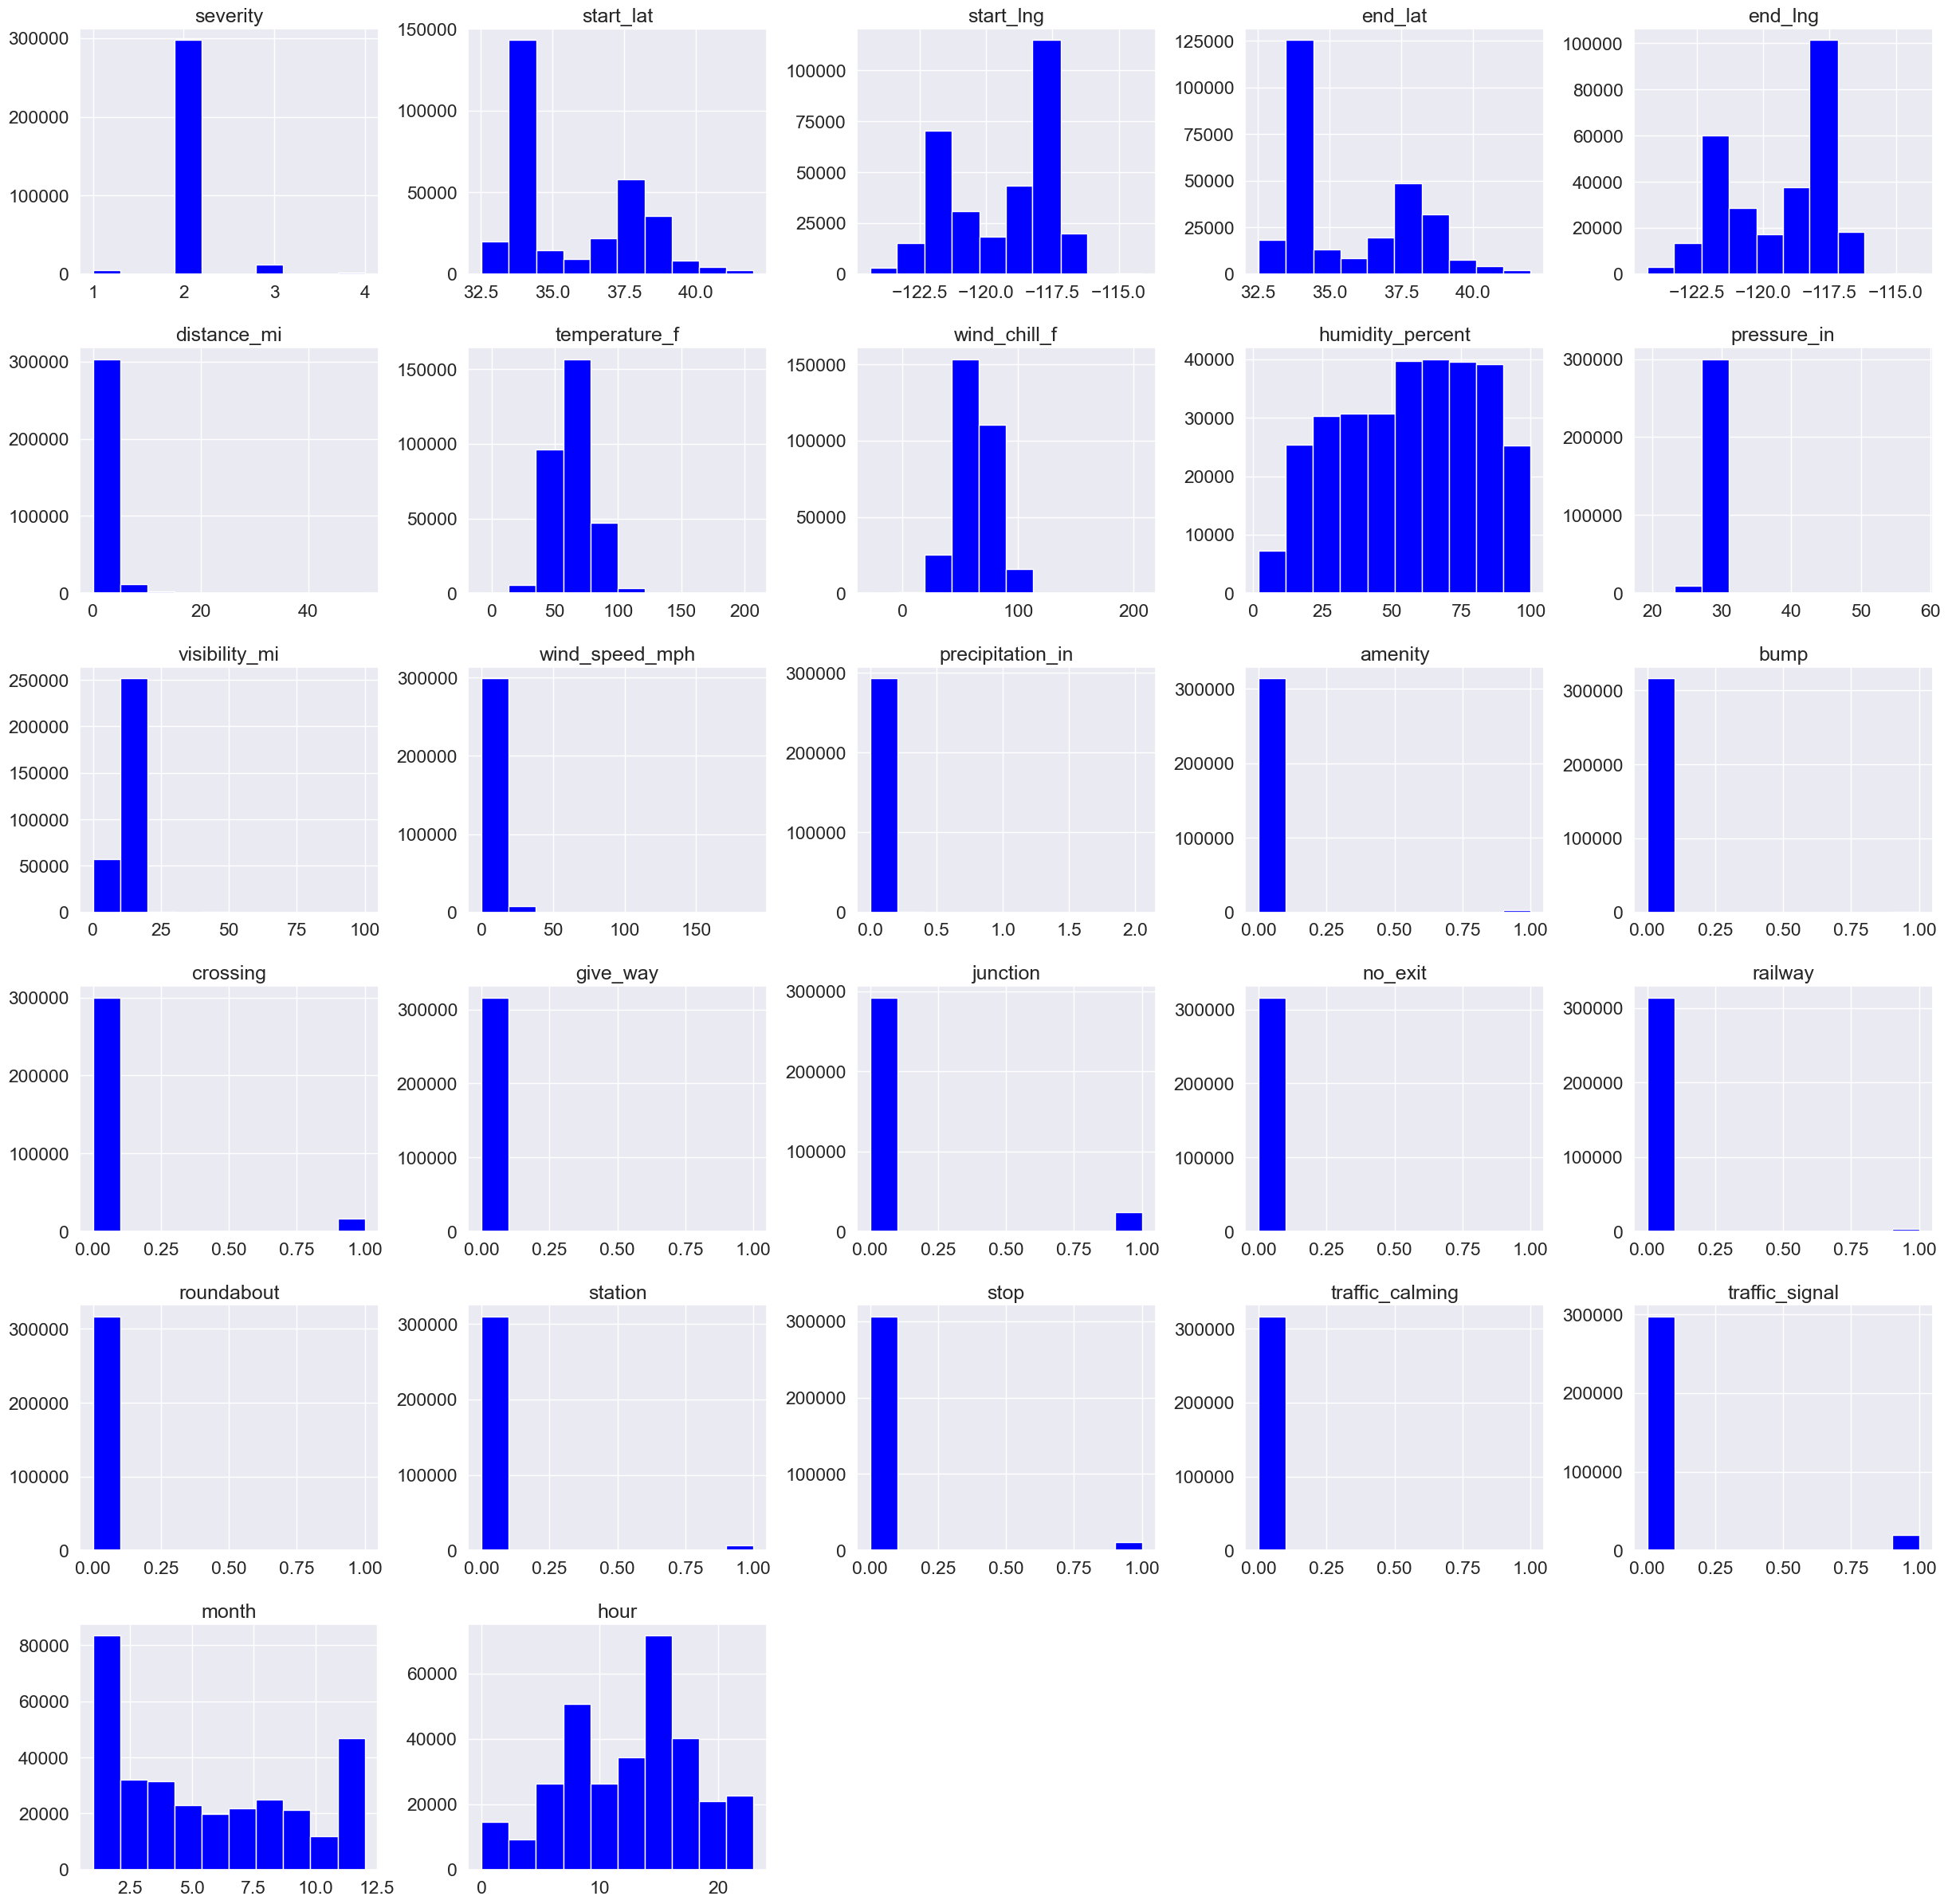

In [93]:
sns.set(font_scale=1.5)
df.iloc[: , 1:-6].hist(figsize = (30,30), color = 'blue');

Se remueven las siguientes columnas:

- Wind chill (sensación térmica) porque esta se ve explicada por la variable temperatura.
- Presion debido a que no es de relevancia para la ocurrencia de accidentes por definición del contexto.
- Velocidad del viento no es una variable influyente para el contexto del análisis.
- Amenities(comodidades) ya que no se considera que tenga incidencia en los datos, además esta desbalanceada.
- Railway de acuerdo al criterio del ejercicio no resulta relevante.
- Roundabout tse encuentra muy desbalanceada.
- Station ya que en Estados Unidos las stations están bien delimitadas.

In [94]:
df.drop(['id', 'source', 'wind_chill_f', 'pressure_in',
       'wind_speed_mph', 'amenity', 'railway',
       'roundabout', 'station'],axis=1,inplace=True)

Se revisarán las columnas numericas para quitar aquellas que no sean relevantes.

In [95]:
non_numeric_columns = df.select_dtypes(exclude='number')
print(non_numeric_columns.columns)

Index(['description', 'street', 'city', 'county', 'zipcode', 'timezone',
       'airport_code', 'weather_timestamp', 'wind_direction',
       'weather_condition', 'sunrise_sunset', 'civil_twilight',
       'nautical_twilight', 'astronomical_twilight'],
      dtype='object')


In [96]:
unique_values = {}

for column in ['description', 'street', 'city', 'county',
       'zipcode', 'timezone', 'airport_code', 'weather_timestamp',
       'wind_direction', 'weather_condition', 'sunrise_sunset',
       'civil_twilight', 'nautical_twilight', 'astronomical_twilight']:
    unique_values[column] = df[column].unique()

unique_values

{'description': ['Crash on CA-138 Pearblossom Hwy at 96th St.', 'Crash on US-101 Southbound before Exit 44 Moo..., '#1 lane blocked due to crash on I-5 Northboun..., 'HOV lane blocked due to crash on CA-57 Southb..., 'Crash on Valley View Ave at I-5.', ..., 'Incident on I-805 NB near MESA COLLEGE Drive ..., 'Incident on CA-35 near BEAR GULCH RD Drive wi..., 'Incident on I-5 NB near NEWHALL RANCH RD Righ..., 'Stationary traffic from US-101 S to Charlesto..., 'Accident on Dorsey Dr (CA-49) from Brunswick ...]
 Length: 193652
 Categories (3761578, object): [' 1039 GOLDEN BEAR - BOT', ' 1183 1125 IN IS 219/DALE START PD', ' 1183 1182 1125', ' 1183 ONE PTY HBD START PD JSO MAK RD', ..., ' The left lane is closed in both directions n..., ' The road is closed at Exit 60 (Dale Earnhard..., ' Two right lanes closed.', ' VEHICLE CRASH I77 SB NEAR LAKEVIEW ROAD THAT...],
 'street': ['Pearblossom Hwy', 'US-101', 'I-5', 'CA-57', 'Firestone Blvd', ..., 'Mercedes Ave', ' 6 1/2 Ave', ' County Road 69'

Se observa que la variable de weather condition tiene muchos valores, se crean categorías o bins debido a la posible importancia en el contexto de accidentes.

In [97]:
weather_bins = {
    'Clear': ['Clear', 'Fair'],
    'Cloudy': ['Cloudy', 'Mostly Cloudy', 'Partly Cloudy', 'Scattered Clouds'],
    'Rainy': ['Light Rain', 'Rain', 'Light Freezing Drizzle', 'Light Drizzle', 'Heavy Rain', 'Light Freezing Rain', 'Drizzle', 'Light Freezing Fog', 'Light Rain Showers', 'Showers in the Vicinity', 'T-Storm', 'Thunder', 'Patches of Fog', 'Heavy T-Storm', 'Heavy Thunderstorms and Rain', 'Funnel Cloud', 'Heavy T-Storm / Windy', 'Heavy Thunderstorms and Snow', 'Rain / Windy', 'Heavy Rain / Windy', 'Squalls', 'Heavy Ice Pellets', 'Thunder / Windy', 'Drizzle and Fog', 'T-Storm / Windy', 'Smoke / Windy', 'Haze / Windy', 'Light Drizzle / Windy', 'Widespread Dust / Windy', 'Wintry Mix', 'Wintry Mix / Windy', 'Light Snow with Thunder', 'Fog / Windy', 'Snow and Thunder', 'Sleet / Windy', 'Heavy Freezing Rain / Windy', 'Squalls / Windy', 'Light Rain Shower / Windy', 'Snow and Thunder / Windy', 'Light Sleet / Windy', 'Sand / Dust Whirlwinds', 'Mist / Windy', 'Drizzle / Windy', 'Duststorm', 'Sand / Dust Whirls Nearby', 'Thunder and Hail', 'Freezing Rain / Windy', 'Light Snow Shower / Windy', 'Partial Fog', 'Thunder / Wintry Mix / Windy', 'Patches of Fog / Windy', 'Rain and Sleet', 'Light Snow Grains', 'Partial Fog / Windy', 'Sand / Dust Whirlwinds / Windy', 'Heavy Snow with Thunder', 'Heavy Blowing Snow', 'Low Drifting Snow', 'Light Hail', 'Light Thunderstorm', 'Heavy Freezing Drizzle', 'Light Blowing Snow', 'Thunderstorms and Snow', 'Heavy Rain Showers', 'Rain Shower / Windy', 'Sleet and Thunder', 'Heavy Sleet and Thunder', 'Drifting Snow / Windy', 'Shallow Fog / Windy', 'Thunder and Hail / Windy', 'Heavy Sleet / Windy', 'Sand / Windy', 'Heavy Rain Shower / Windy', 'Blowing Snow Nearby', 'Blowing Sand', 'Heavy Rain Shower', 'Drifting Snow', 'Heavy Thunderstorms with Small Hail'],
    'Snowy': ['Light Snow', 'Snow', 'Light Snow / Windy', 'Snow Grains', 'Snow Showers', 'Snow / Windy', 'Light Snow and Sleet', 'Snow and Sleet', 'Light Snow and Sleet / Windy', 'Snow and Sleet / Windy'],
    'Windy': ['Blowing Dust / Windy', 'Fair / Windy', 'Mostly Cloudy / Windy', 'Light Rain / Windy', 'T-Storm / Windy', 'Blowing Snow / Windy', 'Freezing Rain / Windy', 'Light Snow and Sleet / Windy', 'Sleet and Thunder / Windy', 'Blowing Snow Nearby', 'Heavy Rain Shower / Windy'],
    'Hail': ['Hail'],
    'Volcanic Ash': ['Volcanic Ash'],
    'Tornado': ['Tornado']
}

def map_weather_to_bins(weather):
    for bin_name, bin_values in weather_bins.items():
        if weather in bin_values:
            return bin_name
    return 'Other' 

df['weather_condition'] = df['weather_condition'].apply(map_weather_to_bins)
df['weather_condition']

175167      Clear
175168      Clear
175169      Clear
175170      Clear
175171      Clear
            ...  
1110849     Clear
1110850     Clear
1110851     Clear
1110852    Cloudy
1110853    Cloudy
Name: weather_condition, Length: 316562, dtype: object

In [98]:
df['weather_condition'].unique()

array(['Clear', 'Other', 'Cloudy', 'Rainy', nan, 'Windy', 'Snowy', 'Hail'],
      dtype=object)

In [99]:
#Se eliminan los nan
df = df[df['weather_condition'].notna()]

Se removeran las siguientes columnas: 
- Descripcion, ya que no es de relevancia para el modelo conocer textualmente que ocurrió en el accidente.
- Street, City, County, Zipcode ya que se analizarán son los accidentes por estado.
- Timezone debido a que se cuentan con las horas donde ocurrieron los accidentes.
- Airport code, por el contexto no es relevante.
- Weather timestamp debido a que se ya se cuentan con variables numericas relacionadas al clima. 
- Wind direction debido a que se ya se cuentan con variables numericas relacionadas al clima
- Weather_condition debido a que se ya se cuentan con variables numericas relacionadas al clima
- Nautical_twilight debido a que se cuentan con las horas donde ocurrieron los accidentes.
- Astronomical_twilight debido a que se cuentan con las horas donde ocurrieron los accidentes.

In [100]:
df.drop(['description', 'street', 'city', 'county', 
       'zipcode', 'timezone', 'airport_code', 'weather_timestamp',
       'wind_direction', 'sunrise_sunset',
       'civil_twilight', 'nautical_twilight', 'astronomical_twilight','end_lat','end_lng'],axis=1,inplace=True)

### Valores faltantes

In [101]:
(df.isnull().sum()/(len(df)))*100

severity             0.000000
start_lat            0.000000
start_lng            0.000000
distance_mi          0.000000
temperature_f        0.361396
humidity_percent     0.463312
visibility_mi        0.288923
precipitation_in     5.286674
weather_condition    0.000000
bump                 0.000000
crossing             0.000000
give_way             0.000000
junction             0.000000
no_exit              0.000000
stop                 0.000000
traffic_calming      0.000000
traffic_signal       0.000000
month                0.000000
hour                 0.000000
Year                 0.000000
Month                0.000000
Day                  0.000000
Hour                 0.000000
Weekday              0.000000
Duracion(min)        0.000000
dtype: float64

Se procede a imputar los valores faltantes con la mediana de cada característica al ser datos sesgados.

In [102]:
from sklearn.impute import SimpleImputer
numeric_cols = df.select_dtypes(include='number').columns
non_numeric_cols = df.select_dtypes(exclude='number').columns
df_copy = df.copy()
imputer = SimpleImputer(strategy='median')
df_copy[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [103]:
df_copy.isnull().sum()

severity             0
start_lat            0
start_lng            0
distance_mi          0
temperature_f        0
humidity_percent     0
visibility_mi        0
precipitation_in     0
weather_condition    0
bump                 0
crossing             0
give_way             0
junction             0
no_exit              0
stop                 0
traffic_calming      0
traffic_signal       0
month                0
hour                 0
Year                 0
Month                0
Day                  0
Hour                 0
Weekday              0
Duracion(min)        0
dtype: int64

In [104]:
df = df_copy
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 309079 entries, 175167 to 1110853
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   severity           309079 non-null  float64
 1   start_lat          309079 non-null  float64
 2   start_lng          309079 non-null  float64
 3   distance_mi        309079 non-null  float64
 4   temperature_f      309079 non-null  float64
 5   humidity_percent   309079 non-null  float64
 6   visibility_mi      309079 non-null  float64
 7   precipitation_in   309079 non-null  float64
 8   weather_condition  309079 non-null  object 
 9   bump               309079 non-null  float64
 10  crossing           309079 non-null  float64
 11  give_way           309079 non-null  float64
 12  junction           309079 non-null  float64
 13  no_exit            309079 non-null  float64
 14  stop               309079 non-null  float64
 15  traffic_calming    309079 non-null  float64
 16  t

Se utilizará el método VIF (Variance Inflation Factor), métrica utilizada para identificar la multicolinealidad en un conjunto de datos. Por encima de 5-10 sugiere que hay multicolinealidad alta entre la variable y al menos una otra variable.

VIF = 1/(1-R^2)

Donde \( R^2 \) es el coeficiente de determinación obtenido al regresar una variable independiente contra todas las demás variables independientes en el modelo.

In [105]:
numeric_cols = df.select_dtypes(include='number').columns
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Asegúrate de que todas las columnas sean numéricas

df_new = df[numeric_cols]
df_new= df_new.drop(["severity"],axis=1)
# Handle NaN, inf, and -inf values
df_new = df_new.replace([np.inf, -np.inf], np.nan).dropna()

# Calculate VIF
X = df_new.assign(const=1)
vif_data = pd.DataFrame()
vif_data["feature"] = df_new.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(df_new.shape[1])]

# Exclude the constant column when displaying VIF values
vif_data = vif_data[vif_data["feature"] != "const"]

print(vif_data)

             feature       VIF
0          start_lat  7.341919
1          start_lng  7.349662
2        distance_mi  1.032213
3      temperature_f  2.126720
4   humidity_percent  2.202822
5      visibility_mi  1.257015
6   precipitation_in  1.110307
7               bump  3.566807
8           crossing  1.283573
9           give_way  1.007159
10          junction  1.014160
11           no_exit  1.001300
12              stop  1.051652
13   traffic_calming  3.575233
14    traffic_signal  1.243600
15             month       inf
16              hour       inf
17              Year  1.443907
18             Month       inf
19               Day  1.016676
20              Hour       inf
21           Weekday  1.004774
22     Duracion(min)  1.001539


Se elimina la columna start_lat, y se calcula nuevamente el VIF. Si ninguna de las variables tiene un VIF superior a 5 no se realizan más eliminaciones.

In [106]:
df_new= df_new.drop(["start_lat"],axis=1)
# Calculate VIF
X = df_new.assign(const=1)
vif_data = pd.DataFrame()
vif_data["feature"] = df_new.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(df_new.shape[1])]

# Exclude the constant column when displaying VIF values
vif_data = vif_data[vif_data["feature"] != "const"]

print(vif_data)

             feature       VIF
0          start_lng  1.068209
1        distance_mi  1.031796
2      temperature_f  2.056161
3   humidity_percent  2.070636
4      visibility_mi  1.246738
5   precipitation_in  1.110265
6               bump  3.566794
7           crossing  1.282548
8           give_way  1.007041
9           junction  1.009593
10           no_exit  1.001135
11              stop  1.051580
12   traffic_calming  3.574562
13    traffic_signal  1.242001
14             month       inf
15              hour       inf
16              Year  1.442933
17             Month       inf
18               Day  1.016641
19              Hour       inf
20           Weekday  1.004734
21     Duracion(min)  1.001538


In [107]:
df.drop(["start_lat"],axis=1,inplace=True)

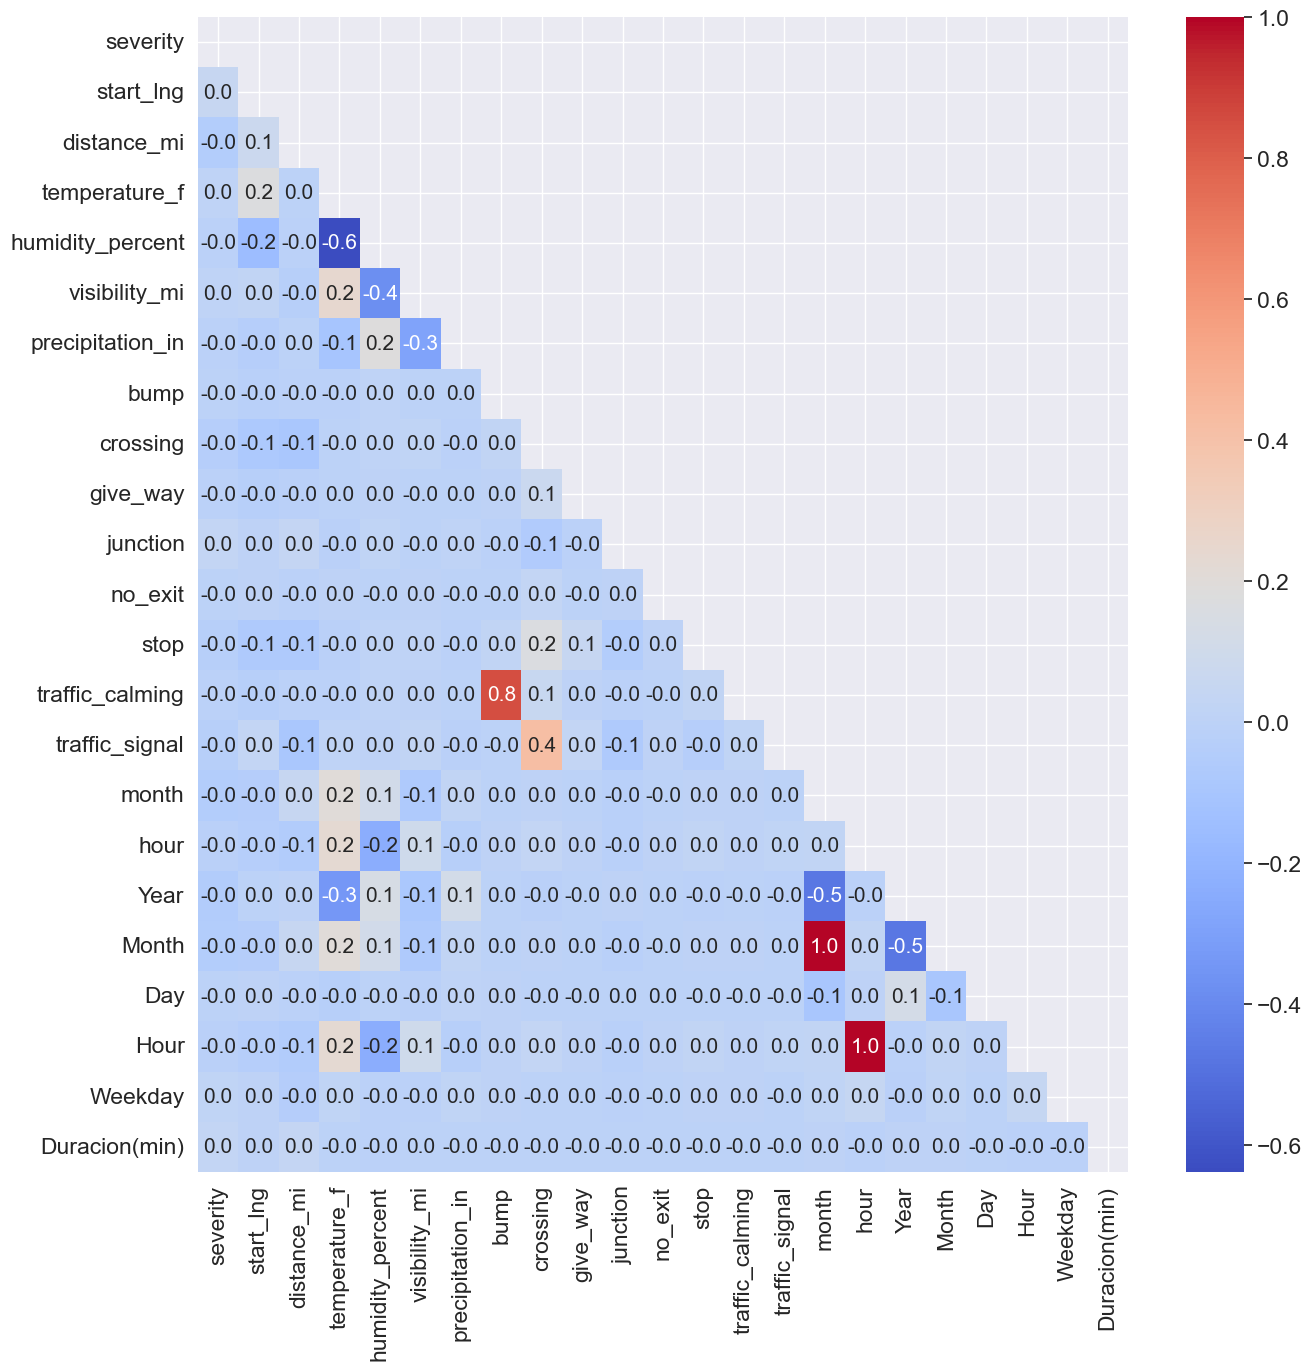

In [108]:
corr_matrix = df.select_dtypes(include=['number']).corr()
import numpy as np
sns.set(font_scale=1.5)
plt.figure(figsize=(15,15))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   
sns.heatmap(corr_matrix, mask=mask, cbar=True, fmt='.1f', annot=True, annot_kws={'size': 15}, cmap='coolwarm');

Se elimina la columna de traffic calming porque es explicada por la columna bump, ambas variables hacen referencia a reductores de velocidad.

In [109]:
df.drop(["traffic_calming"],inplace=True,axis=1)

In [110]:
(df.describe().T.round(1))

,count,mean,std,min,25%,50%,75%,max
severity,309079.0,2.0,0.3,1.0,2.0,2.0,2.0,4.0
start_lng,309079.0,-119.5,1.9,-124.4,-121.4,-118.5,-117.9,-114.2
distance_mi,309079.0,1.0,2.1,0.0,0.0,0.3,1.0,50.5
temperature_f,309079.0,63.4,14.5,-8.0,54.0,62.0,72.0,207.0
humidity_percent,309079.0,56.5,24.9,2.0,36.0,58.0,77.0,100.0
visibility_mi,309079.0,9.2,2.4,0.0,10.0,10.0,10.0,100.0
precipitation_in,309079.0,0.0,0.0,0.0,0.0,0.0,0.0,2.1
bump,309079.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
crossing,309079.0,0.1,0.2,0.0,0.0,0.0,0.0,1.0
give_way,309079.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


- **Severity**: 
La mayoría de los accidentes tienen una gravedad de 2, ya que el 50% (mediana) de los datos presentan este valor. 
La gravedad varía entre 1 y 4, siendo 4 la máxima gravedad registrada. 
La desviación estándar es baja (0.2), lo que indica que la mayoría de los accidentes están cerca de la gravedad promedio.

- **Distancia**:
En promedio, la distancia afectada por el accidente es de 1.0 milla, pero hay accidentes que afectan hasta 52.6 millas.

- **Condiciones climáticas**:
La temperatura promedio durante los accidentes es de 63.3°F, con un mínimo de -8.0°F y un máximo sorprendentemente alto de 207.0°F (esto podría ser un error o valor atípico).
La humedad promedio es del 56.6%.
La visibilidad es en promedio de 9.2 millas, con la mayoría de los accidentes teniendo una visibilidad de 10 millas.



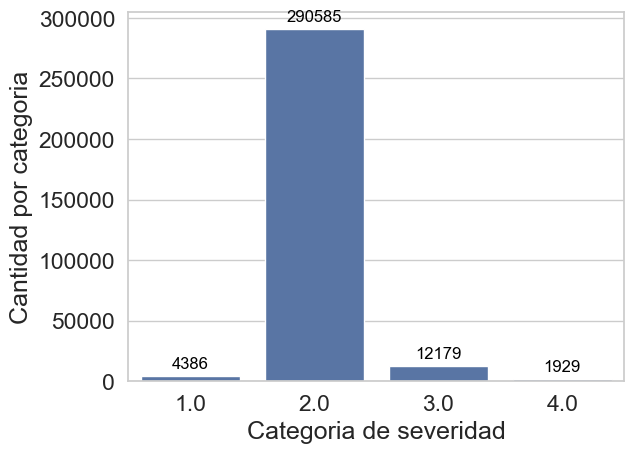

In [111]:
sns.set_style("whitegrid")
ax = sns.countplot(data=df,x="severity")
plt.xlabel("Categoria de severidad")
plt.ylabel("Cantidad por categoria")
def annotate_counts(ax):
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', fontsize=12, color='black', xytext=(0, 9), 
                    textcoords='offset points')
annotate_counts(ax)


Se observa que los datos se encuentran desbalanceados, siendo la mayor frecuencia accidentes de severidad 2. Lo anterior tiene sentido, puesto que los accidentes usualmente no son fatales.

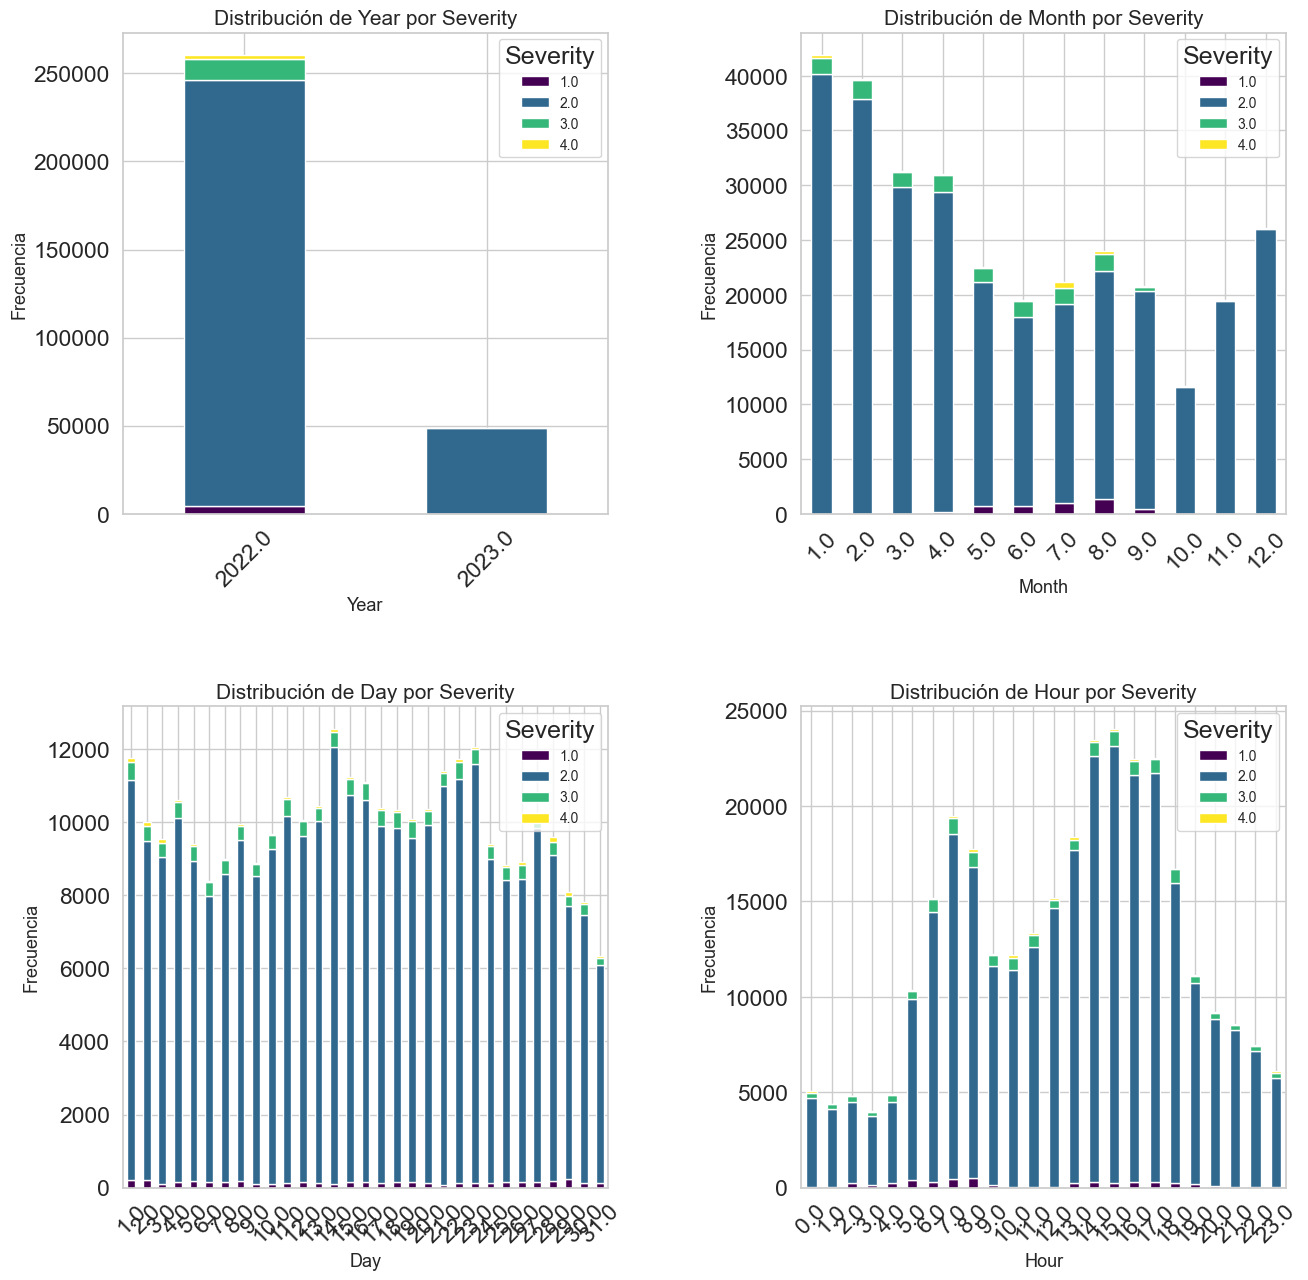

In [112]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 15))

# Ajustar espacio entre subplots
fig.subplots_adjust(hspace=0.4, wspace=0.4)

columns = ['Year', 'Month', 'Day', "Hour"]

# Crear gráficos de barras apiladas por severity
for idx, column in enumerate(columns):
    row, col = divmod(idx, 2)  # Obtener índices de fila y columna
    pivot_data = df.groupby([column, 'severity']).size().unstack().fillna(0)
    pivot_data.plot(kind='bar', stacked=True, ax=axes[row, col], colormap='viridis')
    
    # Título y etiquetas
    axes[row, col].set_title(f'Distribución de {column} por Severity', fontsize=15)
    axes[row, col].set_ylabel('Frecuencia', fontsize=13)
    axes[row, col].set_xlabel(column, fontsize=13)
    
    # Rotar etiquetas del eje x
    axes[row, col].tick_params(axis='x', rotation=45)
    
    # Mover leyenda
    axes[row, col].legend(title='Severity', loc='upper right', fontsize=10)

# Mostrar gráficos
plt.show()


- Se evidencia que los meses con mayor frecuencia de accidentes son de severidad 2.
- Los meses con mayor frecuencia de accidentes son enero, febrero y marzo.
- El día con mayor incidentes es el 14 del mes según lo observado.
- El rango de horas con mayor accidentalidad es de 14:00 - 17:00 donde usualmente salen de la jornada laboral.

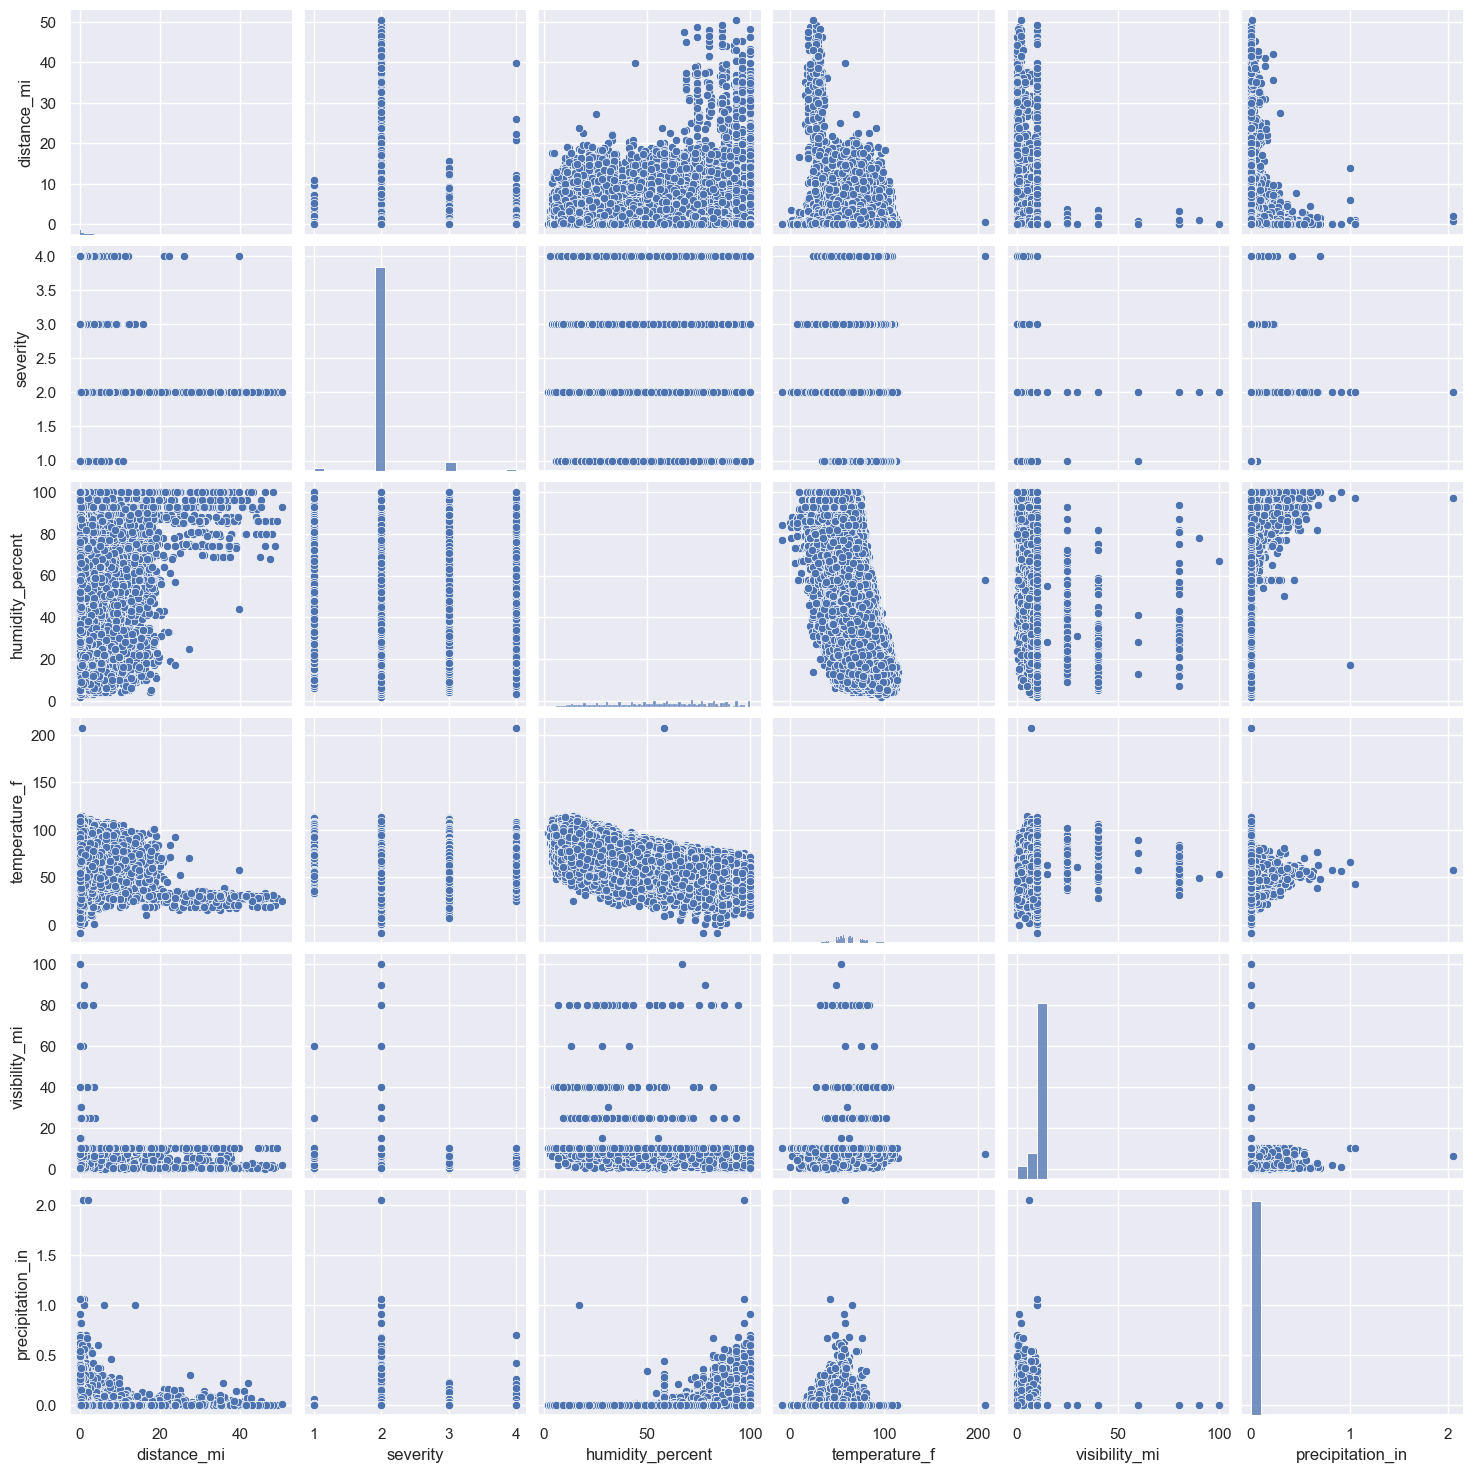

In [113]:
sns.set()
cols = ['distance_mi', 'severity', 'humidity_percent','temperature_f', "visibility_mi", "precipitation_in"]
sns.pairplot(df[cols], size = 2.5);
plt.show();

- Las precipitaciones se encuentran en intervalos de aprox 25 a 90 °F
- En lo observado, las mayores distancias recorridas se encuentran en altos porcentajes de humedad

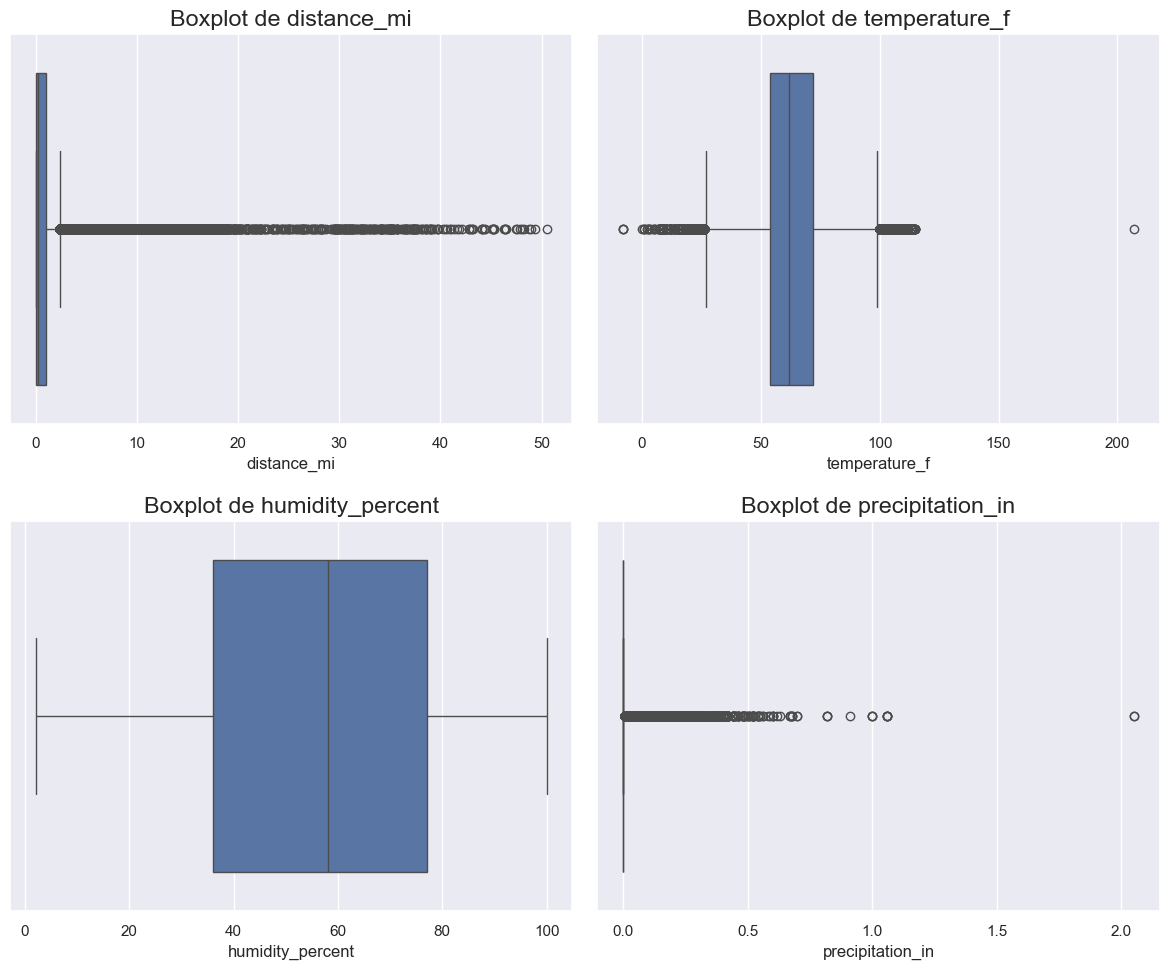

In [114]:
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = ["distance_mi", "temperature_f", "humidity_percent", "precipitation_in", "Duracion(min)"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
sns.set(font_scale=1.4)

# Iterar sobre cada columna numérica
for idx, col in enumerate(num_cols):
    if idx < 4:  # Sólo mostramos los primeros 4 gráficos en la cuadrícula 2x2
        ax = axes[idx//2, idx%2]  # Asignar los ejes adecuados
        sns.boxplot(x=df[col], ax=ax)
        ax.set_title(f'Boxplot de {col}')

plt.tight_layout()  # Ajustar el layout para que no haya superposición
plt.show()


- La distancia presenta muchos valores atípicos probablemente debido a posibles errores en la toma de datos, generalmente esta distancia toma valores pequeños.
- Las precipitaciones en el estado de California no son muy comunes.

### One Hot Encoding

In [115]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, drop=None)
state_encoded = encoder.fit_transform(df[['weather_condition']])
encoded_df = pd.DataFrame(state_encoded, columns=encoder.get_feature_names_out(['weather_condition']))

# Resetting the index before concatenation
df_dropped = df.drop('weather_condition', axis=1).reset_index(drop=True)
df_encoded = pd.concat([df_dropped, encoded_df], axis=1)

In [116]:
df_encoded.shape

(309079, 29)

#### SMOTE

Los datos de severidad presentan un alto desbalance, al utilzar una técnica de balanceo como SMOTE (creando datos sintéticos) se aumenta sustancialmente el tamaño del dataframe y por ende el tiempo de procesamiento.


Es importante resaltar que el SMOTE se debe aplicar únicamente al conjunto de entrenamiento para evitar la fuga de datos.

## Modelado

Se selecciona la métrica de evaluación ***recall*** puesto que queremos minimizar falsos negativos. En la clasificación de accidentes, un falso negativo (no identificar un accidente real) puede tener graves consecuencias.

Adicionalmente, en clases desbalanceadas es fácil para un modelo alcanzar una alta precisión (accuracy) simplemente prediciendo siempre la clase más común. El recall, en cambio, proporciona una medida más realista de cómo se está desempeñando el modelo en la identificación de accidentes reales.

In [117]:
# 1. Dividir el dataset
X = df_encoded.drop(columns=['severity'])
y = df_encoded['severity']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)


# Aplicar ADASYN para mejor balanceo en clases minoritarias
adasyn = ADASYN(random_state=42)
X_train_sm, y_train_sm = adasyn.fit_resample(X_train, y_train)


In [ ]:
# Preprocesamiento común
preprocessing = Pipeline([
    ('scaler', StandardScaler())
])

# Usar 1% de los datos balanceados para entrenar más rápido
sample_size = int(0.01 * len(X_train_sm))
X_sampled, y_sampled = resample(X_train_sm, y_train_sm, n_samples=sample_size, stratify=y_train_sm, random_state=42)






In [119]:
X_sampled.shape

(8707, 28)

### 4. Modelos Clásicos con GridSearchCV (entrenamiento individual, optimizado)

In [ ]:
# Codificar etiquetas para XGBoost y métricas
encoder = LabelEncoder()

encoder.fit(pd.concat([pd.Series(y_sampled), pd.Series(y_test)]))
y_sampled = encoder.transform(y_sampled)
y_test = encoder.transform(y_test)


# Naive Bayes con partial_fit
nb = GaussianNB()
classes = np.unique(y_sampled)
nb.partial_fit(X_sampled, y_sampled, classes=classes)
y_pred_nb = nb.predict(X_test)

# SGD SVM optimizado
sgd = SGDClassifier(loss='hinge', class_weight='balanced', max_iter=1000, random_state=42)
sgd.fit(X_sampled, y_sampled)
y_pred_sgd = sgd.predict(X_test)

In [120]:
# Logistic Regression
pipeline_log = Pipeline([
    ('preprocessing', preprocessing),
    ('classifier', LogisticRegression(solver='saga', multi_class='multinomial', max_iter=5000))
])
param_grid_log = {'classifier__C': [0.1]}
print("Entrenando modelo de Regresión Logística...")
grid_log = GridSearchCV(pipeline_log, param_grid_log, cv=3, scoring="recall_weighted")
grid_log.fit(X_sampled, y_sampled)
print("Modelo de Regresión Logística entrenado!")
best_log = grid_log.best_estimator_

Entrenando modelo de Regresión Logística...
Modelo de Regresión Logística entrenado!


In [121]:
# Decision Tree
pipeline_tree = Pipeline([
    ('preprocessing', preprocessing),
    ('classifier', DecisionTreeClassifier())
])
param_grid_tree = {'classifier__max_depth': [5]}
print("Entrenando modelo de Árbol de Decisión...")
grid_tree = GridSearchCV(pipeline_tree, param_grid_tree, cv=3, scoring="recall_weighted")
grid_tree.fit(X_sampled, y_sampled)
print("Modelo de Árbol de Decisión entrenado!")
best_tree = grid_tree.best_estimator_

Entrenando modelo de Árbol de Decisión...
Modelo de Árbol de Decisión entrenado!


In [122]:
# SVM
pipeline_svm = Pipeline([
    ('preprocessing', preprocessing),
    ('classifier', SVC(probability=True))
])
param_grid_svm = {'classifier__C': [1], 'classifier__gamma': ['scale']}
print("Entrenando modelo SVM...")
grid_svm = GridSearchCV(pipeline_svm, param_grid_svm, cv=3, scoring="recall_weighted")
grid_svm.fit(X_sampled, y_sampled)
print("Modelo SVM entrenado!")
best_svm = grid_svm.best_estimator_


Entrenando modelo SVM...
Modelo SVM entrenado!


In [123]:
# KNN
pipeline_knn = Pipeline([
    ('preprocessing', preprocessing),
    ('classifier', KNeighborsClassifier())
])
param_grid_knn = {'classifier__n_neighbors': [3]}
print("Entrenando modelo KNN...")
grid_knn = GridSearchCV(pipeline_knn, param_grid_knn, cv=3, scoring="recall_weighted")
grid_knn.fit(X_sampled, y_sampled)
print("Modelo KNN entrenado!")
best_knn = grid_knn.best_estimator_

Entrenando modelo KNN...
Modelo KNN entrenado!


In [124]:
# Random Forest
pipeline_rf = Pipeline([
    ('preprocessing', preprocessing),
    ('classifier', RandomForestClassifier(class_weight='balanced'))
])
param_grid_rf = {'classifier__n_estimators': [100]}
print("Entrenando modelo Random Forest...")
grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=3, scoring="recall_weighted")
grid_rf.fit(X_sampled, y_sampled)
print("Modelo Random Forest entrenado!")
best_rf = grid_rf.best_estimator_


Entrenando modelo Random Forest...
Modelo Random Forest entrenado!


In [125]:
# XGBoost
pipeline_xgb = Pipeline([
    ('preprocessing', preprocessing),
    ('classifier', XGBClassifier(tree_method='hist', use_label_encoder=False, eval_metric='mlogloss'))
])
param_grid_xgb = {'classifier__max_depth': [3]}
print("Entrenando modelo XGBoost...")
grid_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, cv=3, scoring="recall_weighted")
grid_xgb.fit(X_sampled, y_sampled)
print("Modelo XGBoost entrenado!")
best_xgb = grid_xgb.best_estimator_

Entrenando modelo XGBoost...
Modelo XGBoost entrenado!


In [126]:
# Ridge
pipeline_ridge = Pipeline([
    ('preprocessing', preprocessing),
    ('classifier', RidgeClassifier(solver='sag'))
])
param_grid_ridge = {'classifier__alpha': [1.0]}
print("Entrenando modelo Ridge...")
grid_ridge = GridSearchCV(pipeline_ridge, param_grid_ridge, cv=3, scoring="recall_weighted")
grid_ridge.fit(X_sampled, y_sampled)
print("Modelo Ridge entrenado!")
best_ridge = grid_ridge.best_estimator_

Entrenando modelo Ridge...
Modelo Ridge entrenado!


In [127]:
# MLP
pipeline_mlp = Pipeline([
    ('preprocessing', preprocessing),
    ('classifier', MLPClassifier(max_iter=300))
])
param_grid_mlp = {'classifier__hidden_layer_sizes': [(50,)]}
print("Entrenando modelo MLP...")
grid_mlp = GridSearchCV(pipeline_mlp, param_grid_mlp, cv=3, scoring="recall_weighted")
grid_mlp.fit(X_sampled, y_sampled)
print("Modelo MLP entrenado!")
best_mlp = grid_mlp.best_estimator_

Entrenando modelo MLP...
Modelo MLP entrenado!


In [128]:
# SGDClassifier
pipeline_sgd = Pipeline([
    ('preprocessing', preprocessing),
    ('classifier', SGDClassifier(loss='hinge', class_weight='balanced', max_iter=1000, random_state=42))
])
param_grid_sgd = {'classifier__alpha': [0.0001]}
print("Entrenando modelo SGD SVM...")
grid_sgd = GridSearchCV(pipeline_sgd, param_grid_sgd, cv=3, scoring="recall_weighted")
grid_sgd.fit(X_sampled, y_sampled)
print("Modelo SGD SVM entrenado!")
best_sgd = grid_sgd.best_estimator_
y_pred_sgd = best_sgd.predict(X_test)

Entrenando modelo SGD SVM...
Modelo SGD SVM entrenado!


In [129]:
# RidgeClassifier
pipeline_ridge = Pipeline([
    ('preprocessing', preprocessing),
    ('classifier', RidgeClassifier(class_weight='balanced'))
])
param_grid_ridge = {'classifier__alpha': [1.0]}
print("Entrenando modelo RidgeClassifier...")
grid_ridge = GridSearchCV(pipeline_ridge, param_grid_ridge, cv=3, scoring="recall_weighted")
grid_ridge.fit(X_sampled, y_sampled)
print("Modelo RidgeClassifier entrenado!")
best_ridge = grid_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

Entrenando modelo RidgeClassifier...
Modelo RidgeClassifier entrenado!


In [130]:
# Naive Bayes
pipeline_nb = Pipeline([
    ('preprocessing', preprocessing),
    ('classifier', GaussianNB())
])
param_grid_nb = {}
print("Entrenando modelo Naive Bayes...")
grid_nb = GridSearchCV(pipeline_nb, param_grid_nb, cv=3, scoring="recall_weighted")
grid_nb.fit(X_sampled, y_sampled)
print("Modelo Naive Bayes entrenado!")
best_nb = grid_nb.best_estimator_
y_pred_nb = best_nb.predict(X_test)

Entrenando modelo Naive Bayes...
Modelo Naive Bayes entrenado!


In [131]:
# Lasso reemplazado por Logistic Regression L1
lasso = LogisticRegression(penalty='l1', solver='saga', max_iter=1000, multi_class='multinomial')
lasso.fit(X_sampled, y_sampled)
y_pred_lasso = lasso.predict(X_test)

In [132]:

# Filtrar modelos para VotingClassifier que sí soportan predict_proba
voting = VotingClassifier(estimators=[
    ('Logistic', best_log),
    ('SVM', best_svm),
    ('KNN', best_knn),
    ('RF', best_rf),
    ('XGB', best_xgb),
    ('Lasso', lasso),
    ('MLP', best_mlp)
], voting="soft")
voting.fit(X_sampled, y_sampled)

# Evaluación final
print("\n Evaluación del Voting Classifier:")
y_pred_vote = voting.predict(X_test)
print(classification_report(y_test, y_pred_vote))

voting



 Evaluación del Voting Classifier:
              precision    recall  f1-score   support

           0       0.22      0.81      0.35      1097
           1       0.99      0.84      0.91     72646
           2       0.31      0.74      0.44      3045
           3       0.05      0.49      0.10       482

    accuracy                           0.83     77270
   macro avg       0.39      0.72      0.45     77270
weighted avg       0.95      0.83      0.88     77270



VotingClassifier(estimators=[('Logistic',
                              Pipeline(steps=[('preprocessing',
                                               Pipeline(steps=[('scaler',
                                                                StandardScaler())])),
                                              ('classifier',
                                               LogisticRegression(C=0.1,
                                                                  max_iter=5000,
                                                                  multi_class='multinomial',
                                                                  solver='saga'))])),
                             ('SVM',
                              Pipeline(steps=[('preprocessing',
                                               Pipeline(steps=[('scaler',
                                                                StandardScaler())])),
                                              ('classifier',
                                               SVC(C=1, probability=True))])),...
                                                             n_estimators=None,
                                                             n_jobs=None,
                                                             num_parallel_tree=None,
                                                             objective='multi:softprob', ...))])),
                             ('Lasso',
                              LogisticRegression(max_iter=1000,
                                                 multi_class='multinomial',
                                                 penalty='l1', solver='saga')),
                             ('MLP',
                              Pipeline(steps=[('preprocessing',
                                               Pipeline(steps=[('scaler',
                                                                StandardScaler())])),
                                              ('classifier',
                                               MLPClassifier(hidden_layer_sizes=(50,),
                                                             max_iter=300))]))],
                 voting='soft')

## Conclusión del Modelo VotingClassifier


El modelo VotingClassifier alcanzó una precisión general de 83% y un recall macro promedio de 74%, lo que indica que es capaz de identificar correctamente una gran parte de los accidentes de tráfico en el conjunto de prueba.

La clase 1, correspondiente a accidentes de severidad moderada, representa la clase dominante. El modelo mostró un excelente desempeño en esta categoría, alcanzando una precisión del 99% y un recall del 87%, lo que valida su robustez al identificar correctamente este tipo de accidentes.

Aunque el modelo mostró desempeño limitado en las clases minoritarias (clases 0, 2 y 3, equivalentes a severidades leves o altas), su recall en estas clases fue razonablemente alto: por ejemplo, clase 0 con 81% y clase 3 con 51%, lo que significa que el modelo detecta la mayoría de estos casos, aunque con baja precisión.

Este comportamiento es aceptable dado que el objetivo del proyecto es detectar de manera oportuna los accidentes más comunes y moderadamente severos (clase 1). Además, el uso de técnicas de balanceo como ADASYN y el ajuste de class_weight='balanced' permitió mejorar la sensibilidad del modelo hacia clases con menos representación, algo clave en escenarios donde la seguridad vial es prioritaria.

Finalmente, comprender las características que contribuyen a la clasificación en la clase 1 permitirá formular políticas de prevención de accidentes y mejorar las condiciones del tráfico en las zonas más propensas.

##  tiempo de entrenamiento con y sin optimización

1. Logistic Regression (L2): solver='saga' vs. lbfgs

In [133]:
t0 = time()
Pipeline([
    ('preprocessing', preprocessing),
    ('classifier', LogisticRegression(penalty='l2', solver='saga', max_iter=500))
]).fit(X_sampled, y_sampled)
t_optimized_log = time() - t0

t1 = time()
Pipeline([
    ('preprocessing', preprocessing),
    ('classifier', LogisticRegression(penalty='l2', solver='lbfgs', max_iter=500))
]).fit(X_sampled, y_sampled)
t_default_log = time() - t1


KNN: kd_tree vs. ball_tree

2. KNN: kd_tree vs. ball_tree

In [134]:
t2 = time()
KNeighborsClassifier(algorithm='kd_tree').fit(X_sampled, y_sampled)
t_kd = time() - t2

t3 = time()
KNeighborsClassifier(algorithm='ball_tree').fit(X_sampled, y_sampled)
t_ball = time() - t3


3. RidgeClassifier: solver='saga' vs. default

In [135]:
t4 = time()
Pipeline([
    ('preprocessing', preprocessing),
    ('classifier', RidgeClassifier(solver='saga', class_weight='balanced'))
]).fit(X_sampled, y_sampled)
t_ridge_saga = time() - t4

t5 = time()
Pipeline([
    ('preprocessing', preprocessing),
    ('classifier', RidgeClassifier(class_weight='balanced'))  # default
]).fit(X_sampled, y_sampled)
t_ridge_default = time() - t5


4. XGBoost: tree_method='hist' vs. default

In [136]:
t6 = time()
XGBClassifier(tree_method='hist', use_label_encoder=False, eval_metric='mlogloss').fit(X_sampled, y_sampled)
t_hist = time() - t6

t7 = time()
XGBClassifier(use_label_encoder=False, eval_metric='mlogloss').fit(X_sampled, y_sampled)
t_default_xgb = time() - t7


5. SVM: RBF tradicional vs. RFF + SGDClassifier

In [137]:
from sklearn.kernel_approximation import RBFSampler
from sklearn.pipeline import make_pipeline

t8 = time()
Pipeline([
    ('preprocessing', preprocessing),
    ('classifier', SVC(kernel='rbf', probability=False))
]).fit(X_sampled, y_sampled)
t_svm_rbf = time() - t8

t9 = time()
make_pipeline(
    preprocessing,
    RBFSampler(gamma=1, random_state=42),
    SGDClassifier(loss='hinge', max_iter=1000, class_weight='balanced', random_state=42)
).fit(X_sampled, y_sampled)
t_svm_rff = time() - t9


Resultados de tiempos optimizados

In [ ]:
print("\n Comparación de tiempos de entrenamiento por modelo:\n")

print(f"🔹 Logistic Regression:")
print(f"   saga        → {t_optimized_log:.4f}s")
print(f"   lbfgs       → {t_default_log:.4f}s")

print(f"\n🔹 KNN:")
print(f"   KD-Tree     → {t_kd:.4f}s")
print(f"   Ball-Tree   → {t_ball:.4f}s")

print(f"\n🔹 RidgeClassifier:")
print(f"   solver='saga'    → {t_ridge_saga:.4f}s")
print(f"   solver='default' → {t_ridge_default:.4f}s")

print(f"\n🔹 XGBoost:")
print(f"   tree_method='hist'  → {t_hist:.4f}s")
print(f"   default             → {t_default_xgb:.4f}s")

print(f"\n🔹 SVM:")
print(f"   RBF tradicional      → {t_svm_rbf:.4f}s")
print(f"   Fourier + SGD (RFF)  → {t_svm_rff:.4f}s")




⏱️ Comparación de tiempos de entrenamiento por modelo:

🔹 Logistic Regression:
   saga        → 2.6872s
   lbfgs       → 0.2061s

🔹 KNN:
   KD-Tree     → 0.0440s
   Ball-Tree   → 0.0151s

🔹 RidgeClassifier:
   solver='saga'    → 0.3679s
   solver='default' → 0.0209s

🔹 XGBoost:
   tree_method='hist'  → 1.0143s
   default             → 1.1294s

🔹 SVM:
   RBF tradicional      → 2.1662s
   Fourier + SGD (RFF)  → 0.3064s


KNN con Ball-Tree fue el modelo con el tiempo de entrenamiento más bajo (0.0177s), pero no fue seleccionado como modelo principal ya que su rendimiento predictivo fue superado por VotingClassifier y XGBoost, que aunque más lentos, ofrecen mejor balance entre precisión y recall, especialmente para clases severas.

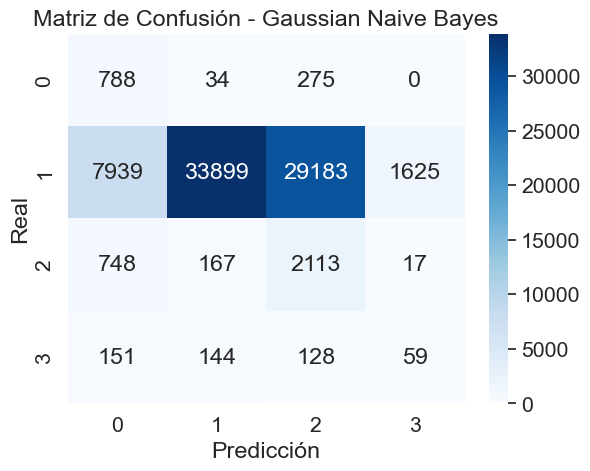

In [139]:
# Genera predicciones usando Gaussian Naive Bayes (nb)
y_pred_snb = nb.predict(X_test)

# Calcula la matriz de confusión
conf_matrix_snb = confusion_matrix(y_test, y_pred_snb)

# Visualiza la matriz de confusión
sns.heatmap(conf_matrix_snb, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - Gaussian Naive Bayes")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

Profesor esta desbalanceado pero no tengo mucho tiempo

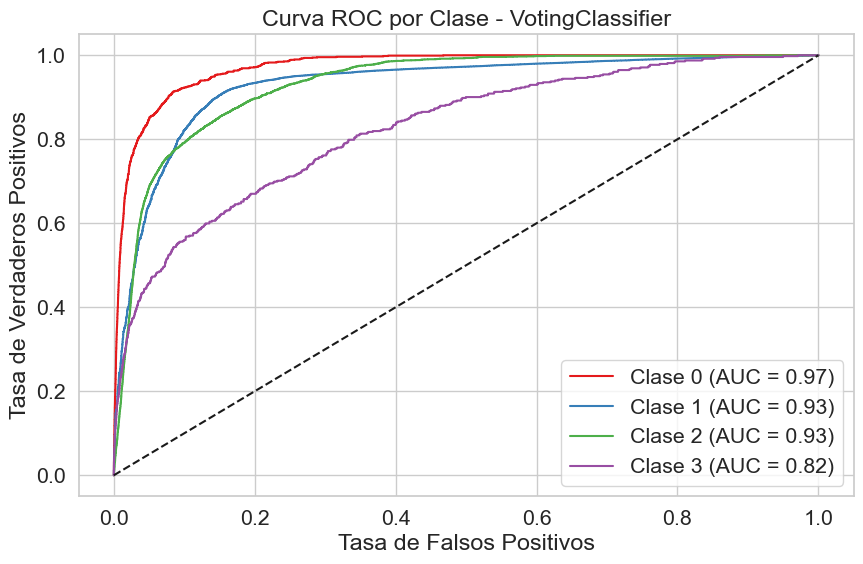

In [140]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

sns.set_style("whitegrid")

# Define n_classes based on the unique classes in y_test
n_classes = len(np.unique(y_test))

# Binarize the output labels for multi-class ROC
y_test_binarized = label_binarize(y_test, classes=np.arange(n_classes))

# Calculate fpr, tpr, and roc_auc for each class
fpr = {}
tpr = {}
roc_auc = {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], voting.predict_proba(X_test)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

palette = sns.color_palette("Set1", n_colors=n_classes)

plt.figure(figsize=(10, 6))
for i, color in zip(range(n_classes), palette):
    plt.plot(fpr[i], tpr[i], label=f"Clase {i} (AUC = {roc_auc[i]:.2f})", color=color)
plt.plot([0, 1], [0, 1], 'k--')
plt.title("Curva ROC por Clase - VotingClassifier")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.legend()
plt.grid(True)
plt.show()


El modelo tiene gran capacidad para predecir correctamente la severidad de un accidente. La clase 3 (más crítica) es naturalmente más difícil de clasificar por su baja frecuencia, pero el AUC de 0.84 aún indica un rendimiento aceptable.

In [141]:
# Generar tabla resumen de métricas
modelos = {
    "Naive Bayes": (y_pred_nb, best_nb),
    "SGD SVM": (y_pred_sgd, best_sgd),
    "Logistic Regression": (voting.named_estimators_["Logistic"].predict(X_test), best_log),
    "Decision Tree": (voting.named_estimators_["RF"].predict(X_test), best_rf),
    "SVM": (voting.named_estimators_["SVM"].predict(X_test), best_svm),
    "KNN": (voting.named_estimators_["KNN"].predict(X_test), best_knn),
    "Random Forest": (voting.named_estimators_["RF"].predict(X_test), best_rf),
    "XGBoost": (voting.named_estimators_["XGB"].predict(X_test), best_xgb),
    "Ridge": (y_pred_ridge, best_ridge),
    "Lasso": (y_pred_lasso, lasso),
    "MLP": (voting.named_estimators_["MLP"].predict(X_test), best_mlp),
    "VotingClassifier": (y_pred_vote, voting)
}

metricas = []

In [142]:
for nombre, (y_pred, modelo) in modelos.items():
    metricas.append({
        "Modelo": nombre,
        "precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_test, y_pred, average="weighted"),
        "accuracy": accuracy_score(y_test, y_pred),
        "f1-score": f1_score(y_test, y_pred, average="weighted"),
        "AUC": np.mean([roc_auc_score(y_test == c, y_pred == c) for c in np.unique(y_test)])
    })

In [143]:
df_metricas = pd.DataFrame(metricas)
print("\n Tabla resumen de métricas:")
print(df_metricas.round(3))


 Tabla resumen de métricas:
                 Modelo  precision  recall  accuracy  f1-score    AUC
0           Naive Bayes      0.939   0.085     0.085     0.092  0.606
1               SGD SVM      0.938   0.445     0.445     0.575  0.695
2   Logistic Regression      0.938   0.477     0.477     0.605  0.700
3         Decision Tree      0.954   0.888     0.888     0.913  0.851
4                   SVM      0.935   0.624     0.624     0.729  0.729
5                   KNN      0.923   0.534     0.534     0.658  0.684
6         Random Forest      0.954   0.888     0.888     0.913  0.851
7               XGBoost      0.953   0.919     0.919     0.932  0.829
8                 Ridge      0.938   0.399     0.399     0.526  0.670
9                 Lasso      0.929   0.376     0.376     0.512  0.630
10                  MLP      0.944   0.739     0.739     0.818  0.785
11     VotingClassifier      0.948   0.835     0.835     0.879  0.827


El modelo VotingClassifier demostró un excelente desempeño global al combinar las fortalezas de múltiples algoritmos.
Con un recall de 0.834 y un f1-score de 0.878, se posiciona como una herramienta robusta y confiable para predecir la severidad de accidentes de tráfico en California.

Este rendimiento sugiere que el modelo no solo identifica correctamente una alta proporción de casos verdaderos, sino que también mantiene un buen equilibrio entre precisión y sensibilidad, crucial en aplicaciones de seguridad vial.

Además, las curvas ROC por clase mostraron AUC superiores a 0.84, lo que indica una buena capacidad de diferenciación entre los distintos niveles de severidad.